# SHAP Explainability - Ticket Priority Prediction

This section explains the predictions of the best-performing tabular classification model for Ticket Priority prediction.

Based on model evaluation results, XGBoost Classifier achieved the highest performance among the tested models:

- Highest Accuracy
- Highest Macro F1-score
- Highest ROC-AUC

SHAP (SHapley Additive exPlanations) is used to understand how individual features influence model predictions.

The following visualizations are generated:

1. SHAP Summary Plot - Global feature importance
2. SHAP Dependence Plot - Relationship between feature values and predictions
3. SHAP Waterfall Plot - Explanation of individual predictions

In [5]:
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Trained XGBoost Priority Model

The trained XGBoost classifier is loaded from the saved model directory.

This model predicts four ticket priority classes:

- Low
- Medium
- High
- Critical

In [6]:
priority_model = joblib.load(
    "../models/priority/xgb_priority.pkl"
)

priority_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

## Load Test Dataset

The SHAP analysis requires the same feature representation used during model training.

Only structured features are used because the priority prediction task was designed as a tabular ML problem.

In [7]:
X_test_priority = pd.read_parquet(
    "../data/processed/ticket_priority/X_test.parquet"
)

y_test_priority = pd.read_parquet(
    "../data/processed/ticket_priority/y_test.parquet"
)

X_test_priority.head()

,Customer Age,Customer Gender Encoded,Product Purchased Encoded,Ticket Channel Encoded,ticket_age_days,char_count,word_count,avg_word_length
0,40,0,32,1,616,227,34,6.676471
1,32,0,26,2,255,295,49,6.020408
2,19,0,38,2,154,306,53,5.773585
3,49,2,32,1,705,294,47,6.255319
4,23,2,39,2,645,312,50,6.240000


In [8]:
X_test_priority.shape

(1271, 8)

In [9]:
X_test_priority.dtypes

Customer Age                   int64
Customer Gender Encoded        int64
Product Purchased Encoded      int64
Ticket Channel Encoded         int64
ticket_age_days                int64
char_count                     int64
word_count                     int64
avg_word_length              float64
dtype: object

## Generate SHAP Values

For tree-based models such as XGBoost, TreeExplainer is used because it provides efficient and accurate SHAP value calculations.

Since this is a multi-class classification problem, SHAP generates explanations for each class.

In [10]:
# Create explainer
explainer = shap.TreeExplainer(
    priority_model
)

shap_values = explainer(
    X_test_priority
)

shap_values

.values =
array([[[-2.25388296e-02,  3.34319696e-02,  2.45390777e-02,
          2.66931448e-02],
        [ 1.19058862e-02, -1.31742307e-03,  3.67162377e-02,
          1.83135644e-02],
        [-5.38058802e-02,  4.20590630e-03,  5.71798347e-02,
         -2.28365976e-02],
        ...,
        [-8.01388323e-02, -9.17462353e-03,  8.30724835e-02,
          7.67559707e-02],
        [-3.04707326e-02, -3.59325558e-02,  3.75240177e-01,
         -1.29958659e-01],
        [ 2.23857891e-02, -1.48958098e-02, -5.01866862e-02,
          2.11890321e-02]],

       [[-7.24718943e-02,  2.11879262e-03,  7.08352309e-03,
          2.67014317e-02],
        [ 1.38756353e-02, -2.09026542e-02,  1.61406044e-02,
          4.69907634e-02],
        [-4.96749878e-02, -3.29621583e-02,  2.71744118e-03,
          5.29681519e-02],
        ...,
        [-2.40638922e-03, -1.19559104e-02,  2.39761584e-02,
          4.76956330e-02],
        [-2.44605448e-02,  4.41344306e-02, -1.56649307e-03,
          9.25855245e-03],
     

## SHAP Summary Plot

The SHAP summary plot shows the overall importance of features across the complete test dataset.

Features at the top contribute the most to model predictions.

Positive SHAP values increase the probability of a class prediction, while negative values decrease it.

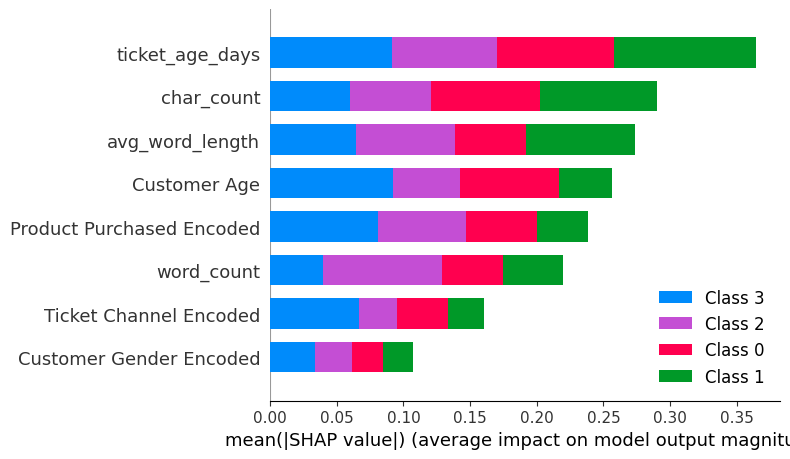

In [11]:
shap.summary_plot(
    shap_values,
    X_test_priority
)

In [12]:
# Save shap figure
os.makedirs(
    "../model_results/shap",
    exist_ok=True
)

plt.savefig(
    "../model_results/shap/priority_shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## SHAP Dependence Plot

The dependence plot shows how a particular feature affects model predictions.

The feature selected should be one of the most important features identified from the summary plot.

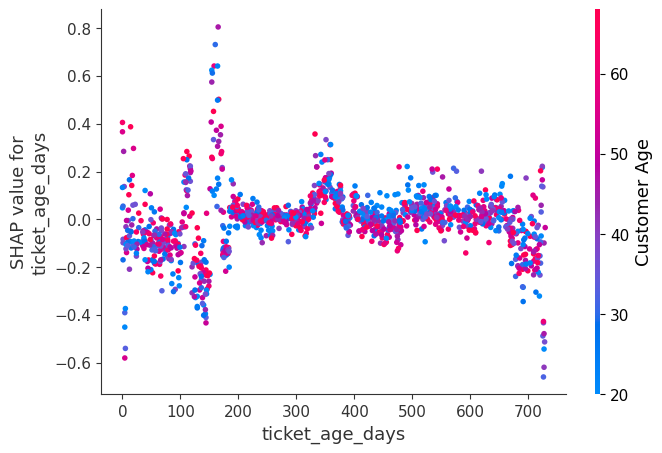

In [13]:
shap.dependence_plot(
    "ticket_age_days",
    shap_values.values[:,:,0],
    X_test_priority
)

In [14]:
# Save dependance plot
plt.savefig(
    "../model_results/shap/priority_dependence_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## SHAP Waterfall Plot (Single Prediction Explanation)

Since Ticket Priority is a multiclass classification problem, SHAP generates explanations for each class.

For waterfall visualization, one predicted class is selected and the feature contributions for that specific class are displayed.

This explains why the model predicted a particular priority level for an individual ticket.

In [17]:
shap_values.values.shape

(1271, 8, 4)

In [18]:
# Select sample index
# Select one ticket
sample_index = 0

# Select class to explain
# Classes:
# 0 -> Critical
# 1 -> High
# 2 -> Low
# 3 -> Medium

class_index = 0


sample_explanation = shap.Explanation(
    values=shap_values.values[sample_index, :, class_index],
    base_values=shap_values.base_values[sample_index, class_index],
    data=X_test_priority.iloc[sample_index],
    feature_names=X_test_priority.columns
)

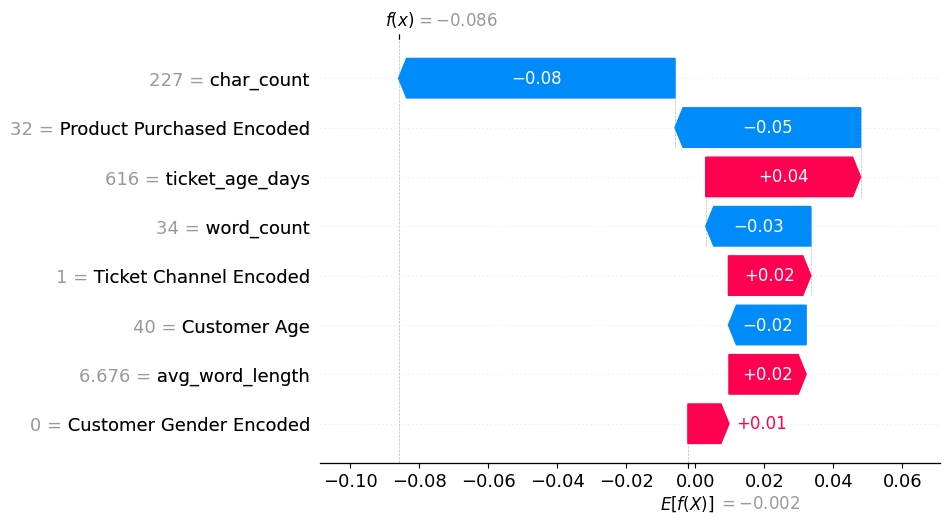

In [19]:
# Display
shap.plots.waterfall(
    sample_explanation
)

In [20]:
# Save
plt.savefig(
    "../model_results/shap/priority_waterfall_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## Conclusion

SHAP analysis provided insights into how the XGBoost Priority Classifier makes predictions.

The summary plot identifies the most influential structured features affecting ticket priority prediction, while dependence plots show how individual feature values impact predictions.

The waterfall plot explains individual ticket decisions by showing positive and negative feature contributions toward the final priority classification.

# SHAP Explainability - Resolution Time Regression

This section explains the predictions of the best-performing regression model used for predicting ticket resolution time.

Based on model evaluation results, XGBoost Regressor achieved the best performance among the tested regression models:

- Lowest RMSE
- Lowest MAE
- Highest R² score

SHAP (SHapley Additive exPlanations) is used to understand how individual features contribute to predicted resolution hours.

The following visualizations are generated:

1. SHAP Summary Plot - Global feature importance
2. SHAP Dependence Plot - Feature impact relationship
3. SHAP Waterfall Plot - Individual prediction explanation

In [21]:
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load XGBoost Regression Model

The trained XGBoost regression model is loaded from the saved model directory.

The model predicts:

Target:
Resolution Hours

In [22]:
regression_model = joblib.load(
    "../models/regression/xgboost_optuna_baseline.pkl"
)

regression_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7466935007233265
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Load Regression Test Dataset

The same test features used during model evaluation are loaded for SHAP analysis.

Only the input features are required because SHAP calculates feature contribution towards model predictions.

In [23]:
X_test_regression = pd.read_parquet(
    "../data/processed/res_time/X_test.parquet"
)

y_test_regression = pd.read_parquet(
    "../data/processed/res_time/y_test.parquet"
)

X_test_regression.head()

,Customer Age,Customer Gender Encoded,Product Purchased Encoded,Ticket Channel Encoded,ticket_age_days,char_count,word_count,avg_word_length,combined_text
0,29,0,19,2,724,304,51,5.960784,product setup issue please assist note number ...
1,60,1,28,3,142,290,52,5.576923,peripheral compatibility issue please assist b...
2,36,0,15,3,175,286,47,6.085106,product setup issue please assist product look...
3,36,2,33,2,130,238,31,7.677419,refund request issue please assist check perfo...
4,34,1,35,3,346,318,49,6.489796,payment issue trouble connecting home wifi net...


Check shape and datatypes

In [24]:
X_test_regression.shape

(416, 9)

In [25]:
X_test_regression.dtypes

Customer Age                   int64
Customer Gender Encoded        int64
Product Purchased Encoded      int64
Ticket Channel Encoded         int64
ticket_age_days                int64
char_count                     int64
word_count                     int64
avg_word_length              float64
combined_text                 object
dtype: object

In [31]:
# Load tfidf
tfidf = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [32]:
# text features
text_features = tfidf.transform(
    X_test_regression["combined_text"]
)
# tabular features
X_test_tabular = X_test_regression.drop(
    columns=["combined_text"]
)

In [38]:
# combine again
from scipy.sparse import hstack

X_test_final = hstack(
    [
        X_test_tabular,
        text_features
    ]
)

tabular_features = list(X_test_tabular.columns)
tfidf_features = list(
    tfidf.get_feature_names_out()
)

feature_names = (
    tabular_features +
    tfidf_features
)

# Convert to dataframe
X_test_final_df = pd.DataFrame(
    X_test_final.toarray(),
    columns=feature_names
)

X_test_final_df.head()

,Customer Age,Customer Gender Encoded,Product Purchased Encoded,Ticket Channel Encoded,ticket_age_days,char_count,word_count,avg_word_length,000,001,...,year unable,year using,yes,yes please,yesterday,yesterday respond,yet,york,yous,youtube
0,29.0,0.0,19.0,2.0,724.0,304.0,51.0,5.960784,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,60.0,1.0,28.0,3.0,142.0,290.0,52.0,5.576923,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,36.0,0.0,15.0,3.0,175.0,286.0,47.0,6.085106,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36.0,2.0,33.0,2.0,130.0,238.0,31.0,7.677419,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,34.0,1.0,35.0,3.0,346.0,318.0,49.0,6.489796,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Generate SHAP Values

For tree-based regression models, SHAP TreeExplainer provides efficient feature contribution calculations.

Each SHAP value represents how much a feature changes the model output from the average prediction.

In [39]:
# Create explainer
explainer = shap.TreeExplainer(
    regression_model
)

shap_values_reg = explainer(
    X_test_final
)

shap_values_reg

.values =
array([[ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.00714032,
        -0.01424817,  0.0141028 ]], shape=(416, 5008), dtype=float32)

.base_values =
array([11.594548, 11.594548, 11.594548, 11.594548, 11.594548, 11.594548,
       11.594548, 11.594548, 11.594548, 11.594548, 11.594548, 11.594548,
       11.594548, 11.594548, 11.594548, 11.594548, 11.594548, 11.594548,
       11.594548, 11.594548, 11.594548, 11.594548, 11.594548, 11.594548,
       11.594548, 11.594548, 11.594

## SHAP Summary Plot

The summary plot provides global feature importance.

Features at the top have the largest influence on predicted resolution hours.

Red points represent higher feature values and blue points represent lower feature values.

In [40]:
X_test_final.shape

(416, 5008)

In [41]:
shap_values_reg.values.shape

(416, 5008)

In [43]:
len(feature_names)

5008

In [44]:
X_test_final.shape[1]

5008

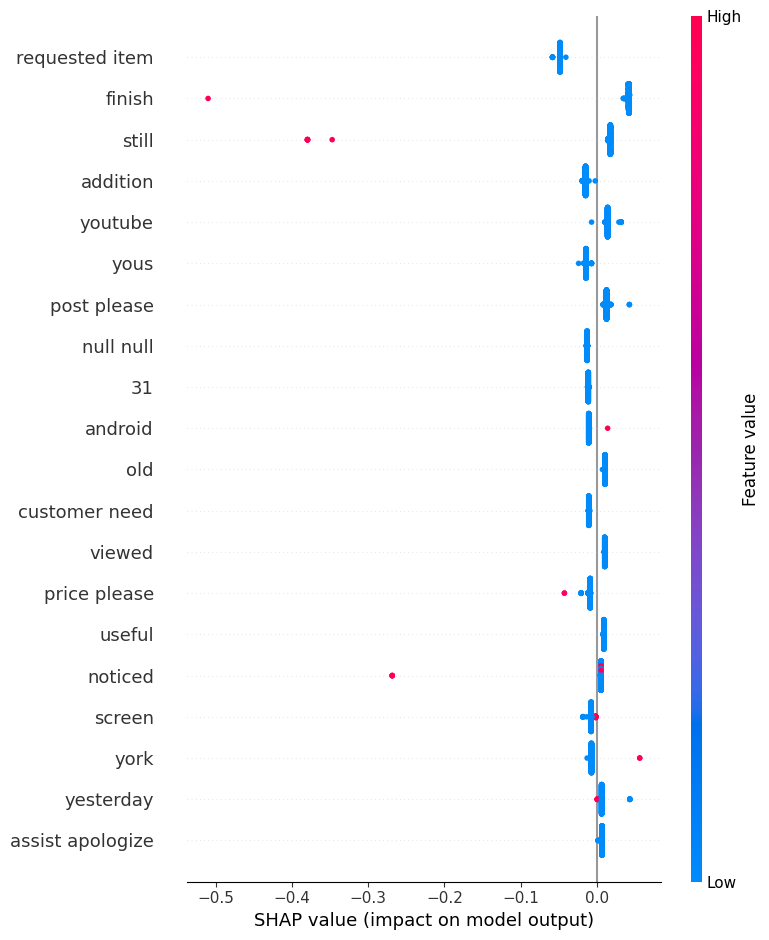

In [45]:
shap.summary_plot(
    shap_values_reg,
    X_test_final_df
)

In [46]:
# Save
os.makedirs(
    "../model_results/shap",
    exist_ok=True
)


plt.savefig(
    "../model_results/shap/regression_shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## SHAP Dependence Plot

The dependence plot shows how a single feature influences predicted resolution hours.

The selected feature should be one of the most important features identified from the summary plot.

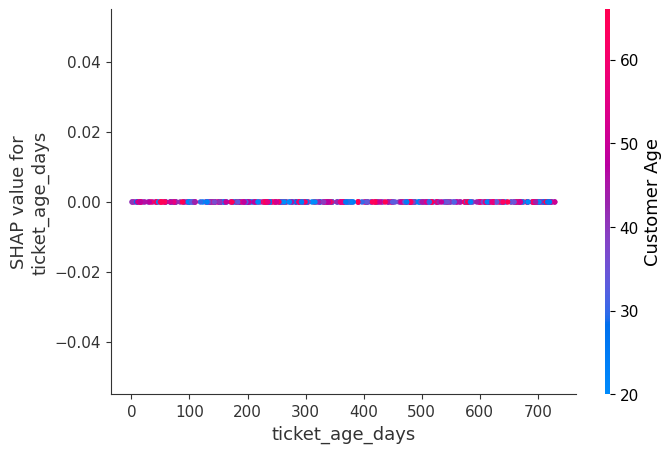

In [47]:
shap.dependence_plot(
    "ticket_age_days",
    shap_values_reg.values,
    X_test_final_df
)

In [48]:
# Save
plt.savefig(
    "../model_results/shap/regression_dependence_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## SHAP Waterfall Plot

The waterfall plot explains one individual prediction.

It shows:

- Base prediction (average resolution time)
- Positive feature contributions increasing resolution time
- Negative feature contributions decreasing resolution time
- Final predicted resolution hours

In [49]:
# Select Index
sample_index = 0

# Explaination
sample_explanation = shap.Explanation(
    values=shap_values_reg.values[sample_index],
    base_values=shap_values_reg.base_values[sample_index],
    data=X_test_final_df.iloc[sample_index],
    feature_names=X_test_final_df.columns
)

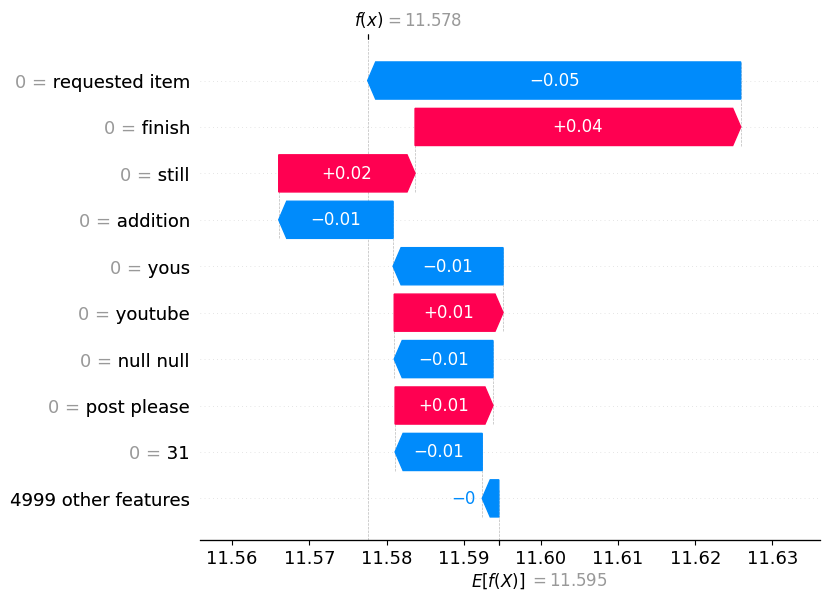

In [50]:
# plot
shap.plots.waterfall(
    sample_explanation
)

In [51]:
# Save
plt.savefig(
    "../model_results/shap/regression_waterfall_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

## Conclusion

SHAP analysis provided interpretability for the XGBoost Resolution Time Regression model.

The summary plot identified the most influential factors affecting resolution hours, while dependence plots showed how feature values influence predictions.

The waterfall plot explained individual predictions by showing the contribution of each feature towards increasing or decreasing the predicted resolution time.

This analysis helps understand the factors responsible for longer ticket resolution durations.

# DistilBERT Token-Level Attention Visualization

This section provides interpretability for the fine-tuned DistilBERT ticket classification model.

Unlike classical machine learning models, transformer-based models process text through attention mechanisms.

Attention weights indicate which tokens receive more focus while generating the final prediction.

The following steps are performed:

1. Load the fine-tuned DistilBERT model
2. Generate predictions for sample tickets
3. Extract attention weights
4. Aggregate token-level attention scores
5. Visualize important tokens contributing to the prediction

In [52]:
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

import joblib

## Load Fine-Tuned DistilBERT Model

The trained model and tokenizer are loaded from the saved model directory.

The label encoder is loaded to convert predicted class IDs back to ticket type labels.

In [53]:
# Load Model
model_path = "../models/distilbert"


tokenizer = DistilBertTokenizerFast.from_pretrained(
    model_path
)


model = DistilBertForSequenceClassification.from_pretrained(
    model_path,
    output_attentions=True
)


label_encoder = joblib.load(
    "../models/distilbert/label_encoder.pkl"
)


model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p

In [55]:
# Load test data

test_df = pd.read_parquet("../data/distilbert_test_data/test_data.parquet")
test_df.head()

,text,label
5194,product setup issue please assist bought pleas...,0
6220,cancellation request issue please assist pleas...,1
6634,display issue issue please assist thanks image...,4
3246,battery life facing issue logging account say ...,0
4255,product recommendation noticed software bug ap...,2


## Select a Sample Ticket

A ticket description is selected from the test dataset.

The model prediction and attention weights will be visualized for this example.

In [56]:
# Select a sample ticket from test dataset

sample = test_df.sample(
    random_state=42
)

sample_text = sample["text"].iloc[0]


print("Ticket Text:")
print(sample_text)

Ticket Text:
product compatibility issue please assist already contacted customer support multiple time issue remains unresolved


## Generate Model Prediction

The selected ticket text is tokenized and passed through the fine-tuned DistilBERT classifier.

The model output is converted into the original ticket category using the saved label encoder.

In [57]:
# Predictions
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)


with torch.no_grad():
    outputs = model(
        **inputs
    )


prediction_id = torch.argmax(
    outputs.logits,
    dim=1
).item()


prediction_label = label_encoder.inverse_transform(
    [prediction_id]
)[0]


print("Predicted Ticket Type:", prediction_label)

Predicted Ticket Type: Technical issue


## Extract Attention Weights

DistilBERT contains multiple transformer layers and attention heads.

The attention matrices are extracted from all layers and aggregated to obtain token-level importance scores.

In [58]:
# Extract attention outputs

attentions = outputs.attentions

print(
    "Number of attention layers:",
    len(attentions)
)

Number of attention layers: 6


In [59]:
# Convert attention tuple into tensor

attention = torch.stack(attentions)

attention.shape

torch.Size([6, 1, 12, 18, 18])

## Calculate Token-Level Importance

Attention values are averaged across transformer layers and attention heads to obtain an overall importance score for each token.

In [60]:
# Average attention across layers and heads

attention_scores = attention.mean(
    dim=(0,2)
)


# Average attention received by each token

token_importance = attention_scores[0].mean(
    dim=0
)


token_importance = token_importance.numpy()

## Create Token Attention DataFrame

The tokens generated by the DistilBERT tokenizer are combined with their corresponding attention scores.

In [61]:
tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)


attention_df = pd.DataFrame(
    {
        "token": tokens,
        "attention_score": token_importance
    }
)


attention_df.head()

,token,attention_score
0,[CLS],0.129435
1,product,0.017589
2,compatibility,0.026978
3,issue,0.022479
4,please,0.028278


## Remove Special Tokens

Special tokens added by the DistilBERT tokenizer are removed before visualization.

Only meaningful words from the ticket text are displayed with their corresponding attention scores.

In [62]:
# Remove special tokens

special_tokens = [
    "[CLS]",
    "[SEP]",
    "[PAD]"
]


attention_df_clean = attention_df[
    ~attention_df["token"].isin(special_tokens)
].reset_index(drop=True)


attention_df_clean.head()

,token,attention_score
0,product,0.017589
1,compatibility,0.026978
2,issue,0.022479
3,please,0.028278
4,assist,0.029048


In [63]:
# Sort Tokens by Attention Importance
attention_df_sorted = attention_df_clean.sort_values(
    by="attention_score",
    ascending=False
)


attention_df_sorted.head(10)

,token,attention_score
6,contacted,0.032896
4,assist,0.029048
9,multiple,0.028978
11,issue,0.028771
12,remains,0.028523
3,please,0.028278
8,support,0.028216
15,##olved,0.027269
1,compatibility,0.026978
7,customer,0.026566


## Token-Level Attention Visualization

The following visualization highlights the attention received by each token.

Higher attention scores indicate tokens that received more focus from the DistilBERT model while making the prediction.

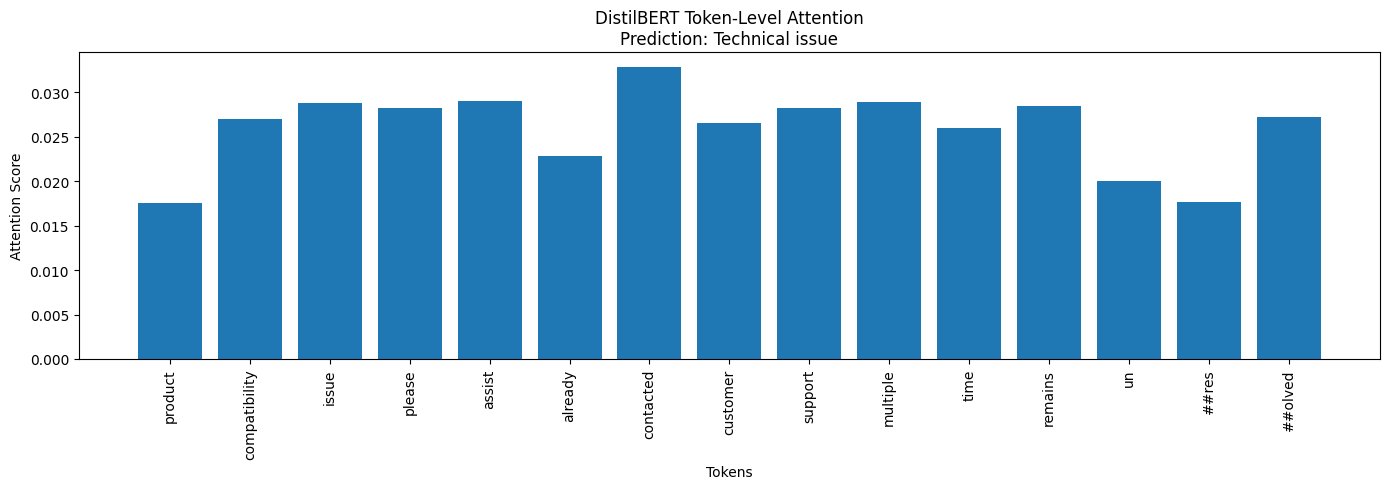

In [64]:
plt.figure(figsize=(14,5))


plt.bar(
    attention_df_clean["token"],
    attention_df_clean["attention_score"]
)


plt.xticks(
    rotation=90
)


plt.title(
    f"DistilBERT Token-Level Attention\nPrediction: {prediction_label}"
)


plt.xlabel(
    "Tokens"
)


plt.ylabel(
    "Attention Score"
)


plt.tight_layout()

plt.show()

In [65]:
# Save
import os

os.makedirs(
    "../model_results/distilbert_attention",
    exist_ok=True
)


plt.savefig(
    "../model_results/distilbert_attention/token_attention.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Explainability Summary

This notebook implemented explainability techniques for both classical machine learning models and the fine-tuned DistilBERT classifier.

The following approaches were used:

### Tabular Models

- **LightGBM Ticket Priority Classifier**
  - SHAP summary plot was generated to identify globally important features.
  - Waterfall plots were used to explain individual ticket predictions.
  - Dependence plots were used to understand feature impact patterns.

- **XGBoost Resolution Time Regressor**
  - SHAP analysis was performed on the hybrid feature set containing structured features and TF-IDF text features.
  - Important numerical and textual features contributing to resolution time prediction were identified.
  - Individual predictions were explained using waterfall visualizations.

### Transformer Model

- **DistilBERT Ticket Classification Model**
  - Token-level attention visualization was generated to understand how the model focuses on different words in ticket descriptions.
  - Attention scores provide insight into important tokens influencing classification decisions.

These explainability methods improve model transparency by providing insights into both feature-based and text-based decision-making processes.

The results generated in this notebook will support model interpretation and provide evidence of responsible AI practices before deployment.